# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import importlib, json, os, pathlib, subprocess, sys, tempfile
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
VERSION = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
EXPECTED_SOURCE_HASH = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
REQUIRED_FILES = ["assets/audio/notebooks/01_el_problema_de_modelar_secuencias_intro.mp3","assets/audio/notebooks/02_tokens_vocabulario_y_batches_intro.mp3","assets/audio/notebooks/03_embeddings_y_geometria_de_tokens_intro.mp3","assets/audio/notebooks/04_posicion_y_orden_en_secuencias_intro.mp3","assets/audio/notebooks/05_tensores_del_transformer_intro.mp3","assets/audio/notebooks/06_atencion_como_mezcla_ponderada_intro.mp3","assets/audio/notebooks/07_queries_keys_y_values_intro.mp3","assets/audio/notebooks/08_self_attention_matricial_intro.mp3","assets/audio/notebooks/09_atencion_causal_intro.mp3","assets/audio/notebooks/10_multi_head_attention_intro.mp3","assets/audio/notebooks/11_residuales_layernorm_y_mlp_intro.mp3","assets/audio/notebooks/12_bloque_transformer_decoder_intro.mp3","assets/audio/notebooks/13_mini_gpt_desde_cero_intro.mp3","assets/audio/notebooks/14_entrenamiento_autoregresivo_intro.mp3","assets/audio/notebooks/15_generacion_interpretacion_y_limites_intro.mp3","assets/audio/notebooks/16_proyecto_final_intro.mp3","assets/audio/presentacion_curso.mp3","assets/figures/00_presentacion_del_curso.png","assets/figures/01_el_problema_de_modelar_secuencias.png","assets/figures/02_tokens_vocabulario_y_batches.png","assets/figures/03_embeddings_y_geometria_de_tokens.png","assets/figures/04_posicion_y_orden_en_secuencias.png","assets/figures/05_tensores_del_transformer.png","assets/figures/06_atencion_como_mezcla_ponderada.png","assets/figures/07_queries_keys_y_values.png","assets/figures/08_self_attention_matricial.png","assets/figures/09_atencion_causal.png","assets/figures/10_multi_head_attention.png","assets/figures/11_residuales_layernorm_y_mlp.png","assets/figures/12_bloque_transformer_decoder.png","assets/figures/13_mini_gpt_desde_cero.png","assets/figures/14_entrenamiento_autoregresivo.png","assets/figures/15_generacion_interpretacion_y_limites.png","assets/figures/16_proyecto_final.png","assets/readings/unit-10-nota-tecnica.pdf","assets/readings/unit-11-nota-tecnica.pdf","assets/readings/unit-12-nota-tecnica.pdf","assets/readings/unit-13-nota-tecnica.pdf","assets/readings/unit-14-nota-tecnica.pdf","assets/readings/unit-15-nota-tecnica.pdf","assets/readings/unit-16-nota-tecnica.pdf","assets/readings/unit-2-nota-tecnica.pdf","assets/readings/unit-3-nota-tecnica.pdf","assets/readings/unit-4-nota-tecnica.pdf","assets/readings/unit-5-nota-tecnica.pdf","assets/readings/unit-6-nota-tecnica.pdf","assets/readings/unit-7-nota-tecnica.pdf","assets/readings/unit-8-nota-tecnica.pdf","assets/readings/unit-9-nota-tecnica.pdf","notebooks/unit-1.ipynb","notebooks/unit-10.ipynb","notebooks/unit-11.ipynb","notebooks/unit-12.ipynb","notebooks/unit-13.ipynb","notebooks/unit-14.ipynb","notebooks/unit-15.ipynb","notebooks/unit-16.ipynb","notebooks/unit-17.ipynb","notebooks/unit-2.ipynb","notebooks/unit-3.ipynb","notebooks/unit-4.ipynb","notebooks/unit-5.ipynb","notebooks/unit-6.ipynb","notebooks/unit-7.ipynb","notebooks/unit-8.ipynb","notebooks/unit-9.ipynb","opencourses-colab.json","requirements.txt","src/fundamentos_transformers/__init__.py","src/fundamentos_transformers/arquitectura_experimentos.py","src/fundamentos_transformers/atencion.py","src/fundamentos_transformers/atencion_experimentos.py","src/fundamentos_transformers/componentes_interactivos.py","src/fundamentos_transformers/datos.py","src/fundamentos_transformers/embeddings.py","src/fundamentos_transformers/entrenamiento.py","src/fundamentos_transformers/entrenamiento_experimentos.py","src/fundamentos_transformers/generacion.py","src/fundamentos_transformers/generacion_experimentos.py","src/fundamentos_transformers/minigpt_experimentos.py","src/fundamentos_transformers/modelo.py","src/fundamentos_transformers/posicion.py","src/fundamentos_transformers/proyecto_final_experimentos.py","src/fundamentos_transformers/tensores.py","src/fundamentos_transformers/tokenizacion.py","src/fundamentos_transformers/visualizacion.py"]
BASE = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
BASE.mkdir(parents=True, exist_ok=True)
TARGET = BASE / VERSION
def _snapshot_issue(folder):
    if not (folder / 'notebooks').is_dir():
        return 'the notebooks folder is missing'
    missing = [name for name in REQUIRED_FILES if not (folder / name).is_file()]
    if missing:
        return 'required files are missing: ' + ', '.join(missing[:5])
    if EXPECTED_SOURCE_HASH:
        try:
            manifest = json.loads((folder / 'opencourses-colab.json').read_text(encoding='utf8'))
        except (OSError, ValueError) as error:
            return f'the publication manifest cannot be read: {error}'
        if manifest.get('source_hash') != EXPECTED_SOURCE_HASH:
            return 'the publication version has changed; reopen the latest notebook from OpenCourses.AI'
    return None
if _snapshot_issue(TARGET) is not None:
    recoveries = sorted(BASE.glob(VERSION + '-recovery-*'), key=lambda folder: folder.stat().st_mtime, reverse=True)
    existing = next((folder for folder in recoveries if _snapshot_issue(folder) is None), None)
    if existing is not None:
        TARGET = existing
    elif TARGET.exists():
        print('The course folder is incomplete. Preserving it and downloading a fresh copy.')
        TARGET = pathlib.Path(tempfile.mkdtemp(prefix=VERSION + '-recovery-', dir=BASE))
if _snapshot_issue(TARGET) is not None:
    print('Downloading the course resources...')
    try:
        subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
    except Exception as error:
        raise RuntimeError(f'Course download failed. Files in {TARGET} were preserved. Run setup again to retry in a fresh folder.') from error
    issue = _snapshot_issue(TARGET)
    if issue is not None:
        raise RuntimeError(f'Course setup stopped: {issue}. Files in {TARGET} were preserved; no course code was started.')
else:
    print('Using the verified folder for this course version; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir():
    if str(src_dir) in sys.path:
        sys.path.remove(str(src_dir))
    sys.path.insert(0, str(src_dir))
importlib.invalidate_caches()
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 05</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Tensores del Transformer</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/05_tensores_del_transformer_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Qué significan realmente las formas $(B,T,C)$ y $(B,H,T,D)$ dentro de un Transformer?

Los notebooks anteriores construyeron índices, embeddings de token y embeddings posicionales. Ahora necesitamos leer con precisión los ejes que aparecen cuando esas representaciones entran a proyecciones lineales y se dividen en cabezas.

Muchos errores sobre Transformers son errores de forma: confundir batch, tiempo, canales, cabezas o dimensión por cabeza. Este notebook busca convertir esas formas en objetos interpretables, no en detalles de PyTorch.

## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Definir el significado de los ejes $B$, $T$, $C$, $H$ y $D$.
2. Explicar cómo una proyección lineal produce conjuntamente $Q$, $K$ y $V$.
3. Reorganizar tensores desde $(B,T,C)$ hasta $(B,H,T,D)$ y justificar cada cambio de eje.
4. Verificar por qué $C$ debe ser divisible por $H$ cuando se divide en cabezas.
5. Usar una auditoría de formas para detectar inconsistencias conceptuales antes de implementar atención.

## Marco conceptual

Un Transformer procesa lotes de secuencias. Cada posición contiene un vector con $C$ canales. Cuando se introduce atención multi-head, esos canales se dividen en $H$ grupos llamados cabezas, cada una con dimensión $D$.

La forma $(B,T,C)$ no es decoración: $B$ organiza ejemplos, $T$ organiza posiciones y $C$ organiza rasgos vectoriales. La forma $(B,H,T,D)$ agrega un eje de cabezas para que varias comparaciones de atención ocurran en paralelo sobre subespacios distintos.

Este notebook no introduce todavía la atención completa. Prepara la alfabetización tensorial necesaria para que, en el siguiente tramo, $Q$, $K$, $V$, scores, máscaras y pesos no aparezcan como una caja negra.

Conviene leer cada operación con una pregunta:

| Operación | Pregunta conceptual |
|---|---|
| proyección lineal | ¿qué nuevos canales se calculan por posición? |
| separación $Q/K/V$ | ¿qué rol tendrá cada grupo de canales? |
| división en cabezas | ¿cómo se reparte $C$ en $H$ subespacios? |
| transposición | ¿qué eje conviene poner antes para calcular atención? |

## Idea visual: leer los ejes del Transformer

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/05_tensores_del_transformer.png" alt="Ejes tensoriales y reorganización en cabezas del Transformer" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura muestra que las formas tensoriales no son decoración técnica: cada eje tiene un significado computacional. Las proyecciones y la separación en cabezas reorganizan esos ejes para preparar atención, pero no eliminan su interpretación.

## Formulación matemática

Supongamos un tensor de entrada:

$$
X \in \mathbb{R}^{B \times T \times C}.
$$

Esta ecuación se lee así: hay $B$ secuencias en el batch, $T$ posiciones por secuencia y $C$ canales por posición.

Una proyección lineal puede producir conjuntamente consultas, llaves y valores:

$$
QKV = XW, \qquad W \in \mathbb{R}^{C \times 3C}, \qquad QKV \in \mathbb{R}^{B \times T \times 3C}.
$$

Esta ecuación se lee así: en cada posición, un vector de $C$ canales se transforma en un vector de $3C$ canales. La operación se aplica por posición: no mezcla posiciones todavía. El eje $3C$ contiene tres grupos de canales que luego se leerán como $Q$, $K$ y $V$.

Después de separar esos tres grupos:

$$
Q,K,V \in \mathbb{R}^{B \times T \times C}.
$$

Esta ecuación se lee así: cada uno conserva batch y tiempo, pero tiene sus propios canales proyectados.

Para dividir en cabezas se exige:

$$
C = H D.
$$

Esta ecuación se lee así: los $C$ canales se reparten en $H$ cabezas, cada una con $D$ canales. Si $C$ no es divisible por $H$, la partición uniforme no está definida.

La reorganización típica es:

$$
(B,T,C) \rightarrow (B,T,H,D) \rightarrow (B,H,T,D).
$$

Esta ecuación se lee así: primero se separa el eje de canales en cabezas y dimensión por cabeza; luego se mueve el eje de cabezas antes del tiempo para operar atención por cabeza.


## Traducción tensorial

`view` o `reshape` cambian cómo se agrupan los mismos valores; `transpose` cambia el orden de los ejes. Conceptualmente, ninguna de estas operaciones debe ocultar qué representa cada dimensión.

El foco no es memorizar una receta de PyTorch, sino poder auditar si una operación conserva el significado de batch, tiempo, canales y cabezas.


## Lectura de ejes

| Eje | Nombre | Pregunta que responde | En una forma como... |
|---|---|---|---|
| $B$ | batch | ¿cuántas secuencias se procesan en paralelo? | $(B,T,C)$ |
| $T$ | tiempo | ¿cuántas posiciones tiene cada secuencia? | $(B,T,C)$ |
| $C$ | canales | ¿cuántos rasgos tiene cada posición? | $(B,T,C)$ |
| $H$ | heads | ¿en cuántos subespacios se divide la atención? | $(B,H,T,D)$ |
| $D$ | dimensión por head | ¿cuántos canales recibe cada cabeza? | $(B,H,T,D)$ |

Esta tabla se usa como auditoría: cada vez que una operación cambia una forma, debemos poder decir qué eje cambió, qué eje se conservó y qué significado computacional tiene.


## Nota práctica: `view`, `transpose` y contigüidad

En PyTorch, `view` interpreta un bloque de memoria con una forma nueva. `transpose` cambia el orden lógico de los ejes, pero puede dejar el tensor no contiguo en memoria. Por eso, después de un `transpose`, a veces se usa `.contiguous()` antes de volver a llamar `view`.

En este notebook no profundizaremos en memoria, pero la advertencia importa: un error de forma puede ser conceptual, y un error de contigüidad puede ser una consecuencia práctica de cómo se reordenaron los ejes.


## Preparación del entorno

In [1]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings("ignore", message="Pandas requires version.*")

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.tensores as tensores
import fundamentos_transformers.visualizacion as visualizacion

tensores = importlib.reload(tensores)
visualizacion = importlib.reload(visualizacion)
configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento: auditoría de formas

Aplicaremos una proyección $QKV$, separaremos $Q$, $K$ y $V$, y reorganizaremos los tres tensores por cabezas. Cada paso se reporta como auditoría: forma antes, forma después, eje que cambia y eje que se conserva.


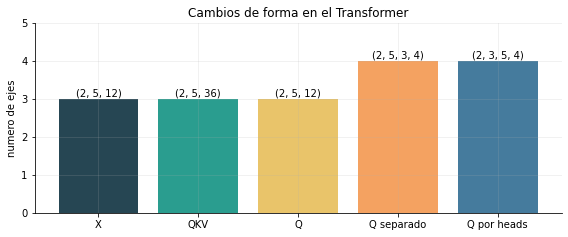

In [2]:
resultado_formas = tensores.preparar_auditoria_formas_transformer(
    batch_size=2,
    seq_len=5,
    n_embd=12,
    n_head=3,
    seed=7,
)

mostrar_tablas_en_columnas(
    [
        ("Auditoría eje por eje", resultado_formas.auditoria),
        ("Tensores resultantes", resultado_formas.tensores),
    ],
    min_width="520px",
)

display(resultado_formas.figura)
plt.close(resultado_formas.figura)


La auditoría muestra que $Q$, $K$ y $V$ no aparecen como objetos opacos. Son resultados de una proyección lineal por posición y de reorganizaciones controladas de ejes.

La forma $(B,H,T,D)$ prepara el cálculo de atención por cabeza: cada cabeza verá las $T$ posiciones usando $D$ canales, mientras el eje $B$ mantiene separados los ejemplos del batch.


## Explorador interactivo de formas tensoriales

El siguiente explorador permite modificar $B$, $T$, $C$ y $H$. La variable clave es $C$: para dividir canales en cabezas, debe poder escribirse como $C=HD$.

In [3]:
import fundamentos_transformers.componentes_interactivos as componentes_interactivos

componentes_interactivos = importlib.reload(componentes_interactivos)

explorador_tensores = componentes_interactivos.crear_explorador_tensores_transformer(
    b_inicial=2,
    t_inicial=5,
    c_inicial=12,
    h_inicial=3,
)
display(explorador_tensores)

## Verificación de divisibilidad

La división en cabezas exige una partición uniforme de los canales. Si $C$ no es divisible por $H$, no existe un $D$ entero que permita reorganizar $(B,T,C)$ como $(B,T,H,D)$ sin cambiar la arquitectura.

In [4]:
resultado_divisibilidad = tensores.preparar_verificacion_divisibilidad()

mostrar_tablas_en_columnas(
    [
        ("Casos de divisibilidad", resultado_divisibilidad.divisibilidad),
        ("Diagnóstico controlado", resultado_divisibilidad.diagnostico),
    ],
    min_width="420px",
)


C,H,C divisible por H,D = C/H si aplica,lectura
12,3,si,4,particion uniforme posible
12,4,si,3,particion uniforme posible
10,3,no,no definido,no se puede dividir en cabezas iguales
16,8,si,2,particion uniforme posible
caso,intento,problema,resultado,correccion
"C=10, H=3","view(1,2,3,3)","3 x 3 = 9 canales, pero C=10",RuntimeError capturado: no hay D entero que conserve todos los valores,elegir otro C o cambiar H


## Interpretación

Si $C$ no es divisible por $H$, no se puede repartir el eje de canales en cabezas del mismo tamaño usando una vista simple. Este no es solo un error de implementación: significa que la arquitectura no definió una partición coherente de canales.

La auditoría eje por eje evita memorizar formas. Una proyección cambia canales, `chunk` separa roles, `view` reagrupa canales como cabezas y `transpose(1,2)` pone el eje $H$ antes de $T$ para operar atención por cabeza.

La atención completa usará estas formas para comparar posiciones. Por eso la alfabetización tensorial no es un detalle secundario; es la base para entender qué se multiplica, qué se mezcla y qué eje representa cada cosa.

El explorador ayuda a distinguir cambios de escala: aumentar $B$ cambia cuántos ejemplos se procesan, aumentar $T$ cambia cuántas posiciones interactuarán, aumentar $C$ cambia los canales por posición y cambiar $H$ modifica cómo se divide ese espacio en cabezas.


## Verificación de aprendizaje

Use el explorador interactivo y cambie una sola variable entre $B$, $T$, $C$ y $H$. Luego reporte evidencia concreta:

1. la nueva forma de $X$;
2. la forma de $QKV$ y por qué el último eje es $3C$;
3. la forma de $Q$, $K$ y $V$ antes y después de dividir en cabezas;
4. si $C=H \cdot D$ se cumple;
5. qué eje cambia en `view(B,T,H,D)`;
6. qué eje cambia en `transpose(1,2)`;
7. una explicación de qué eje representa posiciones y cuál representa canales.


## Análisis crítico

Leer formas no equivale a entender todo el Transformer, pero evita errores de base. Si no se distingue el eje temporal del eje de canales, es fácil malinterpretar atención como una mezcla de rasgos cuando en realidad compara posiciones y mezcla valores.

La tabla de formas también ayuda a depurar modelos reales: una excepción de dimensión suele indicar una inconsistencia conceptual previa.

## Síntesis

$$
X \rightarrow QKV \rightarrow (Q,K,V) \rightarrow (B,T,H,D) \rightarrow (B,H,T,D)
$$

Esta cadena se lee así: la entrada con batch, tiempo y canales se proyecta, se separa en consultas, llaves y valores, y luego se reorganiza para calcular atención por cabeza.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin: 14px 0;">
La idea central es que cada eje tiene significado. La atención no se entiende memorizando formas, sino sabiendo qué representa cada dimensión y por qué se reorganiza.
</div>

## Preguntas de discusión

1. ¿Qué eje representa posiciones y cuál representa rasgos o canales?
2. ¿Por qué $C$ debe ser divisible por $H$ para multi-head attention?
3. ¿Qué diferencia conceptual hay entre `view` y `transpose` en esta auditoría?
4. ¿Por qué $QKV$ tiene $3C$ canales antes de separarse?
5. ¿Cómo prepara la forma $(B,H,T,D)$ el cálculo de atención del siguiente notebook?

## Continuidad

Con las formas claras, el siguiente notebook introduce atención como mezcla ponderada antes de Q/K/V completos. Allí las formas dejarán de ser solo auditoría y empezarán a describir rutas de información entre posiciones.